<a href="https://colab.research.google.com/github/SBethune103/virtual-running-coach-pipeline/blob/main/notebooks/04_basic_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q polars pyarrow scikit-learn matplotlib seaborn

import polars as pl
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")

BASE = Path("/content/drive/MyDrive/virtual-running-coach")
DATA_PROCESSED = BASE / "data/processed"

print("✅ Setup complete")

Mounted at /content/drive
✅ Setup complete


In [ ]:
# Load athlete summary (lightweight)
athlete_df = pl.read_parquet(DATA_PROCESSED / "athlete_summary.parquet")
print(f"Athletes loaded: {athlete_df.shape[0]:,}")
print(athlete_df.head())

Athletes loaded: 36,412
shape: (5, 10)
┌─────────┬────────────┬────────────┬────────────┬───┬────────┬───────────┬────────────┬───────────┐
│ athlete ┆ total_dist ┆ avg_weekly ┆ weeks_acti ┆ … ┆ gender ┆ age_group ┆ country    ┆ consisten │
│ ---     ┆ ance_km    ┆ _distance  ┆ ve         ┆   ┆ ---    ┆ ---       ┆ ---        ┆ cy_score  │
│ i64     ┆ ---        ┆ ---        ┆ ---        ┆   ┆ str    ┆ str       ┆ str        ┆ ---       │
│         ┆ f64        ┆ f64        ┆ u32        ┆   ┆        ┆           ┆            ┆ f64       │
╞═════════╪════════════╪════════════╪════════════╪═══╪════════╪═══════════╪════════════╪═══════════╡
│ 31697   ┆ 1972.555   ┆ 31.310397  ┆ 63         ┆ … ┆ M      ┆ 18 - 34   ┆ United     ┆ 31.310397 │
│         ┆            ┆            ┆            ┆   ┆        ┆           ┆ Kingdom    ┆           │
│ 9633    ┆ 835.3025   ┆ 16.37848   ┆ 51         ┆ … ┆ F      ┆ 18 - 34   ┆ United     ┆ 16.37848  │
│         ┆            ┆            ┆            ┆  

In [ ]:
print("=== Distribution of Weekly Distance ===")
print(athlete_df.select("avg_weekly_distance").describe())

print("\n=== Average Pace by Age Group ===")
print(
    athlete_df
    .group_by("age_group")
    .agg([
        pl.col("avg_pace").mean().alias("mean_pace"),
        pl.col("avg_weekly_distance").mean().alias("mean_distance"),
        pl.len().alias("n_athletes")
    ])
    .sort("age_group")
)

=== Distribution of Weekly Distance ===
shape: (9, 2)
┌────────────┬─────────────────────┐
│ statistic  ┆ avg_weekly_distance │
│ ---        ┆ ---                 │
│ str        ┆ f64                 │
╞════════════╪═════════════════════╡
│ count      ┆ 36412.0             │
│ null_count ┆ 0.0                 │
│ mean       ┆ 34.335628           │
│ std        ┆ 21.433997           │
│ min        ┆ 0.04                │
│ 25%        ┆ 18.871034           │
│ 50%        ┆ 29.089986           │
│ 75%        ┆ 44.624244           │
│ max        ┆ 287.119625          │
└────────────┴─────────────────────┘

=== Average Pace by Age Group ===
shape: (3, 4)
┌───────────┬───────────┬───────────────┬────────────┐
│ age_group ┆ mean_pace ┆ mean_distance ┆ n_athletes │
│ ---       ┆ ---       ┆ ---           ┆ ---        │
│ str       ┆ f64       ┆ f64           ┆ u32        │
╞═══════════╪═══════════╪═══════════════╪════════════╡
│ 18 - 34   ┆ 5.752073  ┆ 33.562476     ┆ 12242      │
│ 35 - 54   

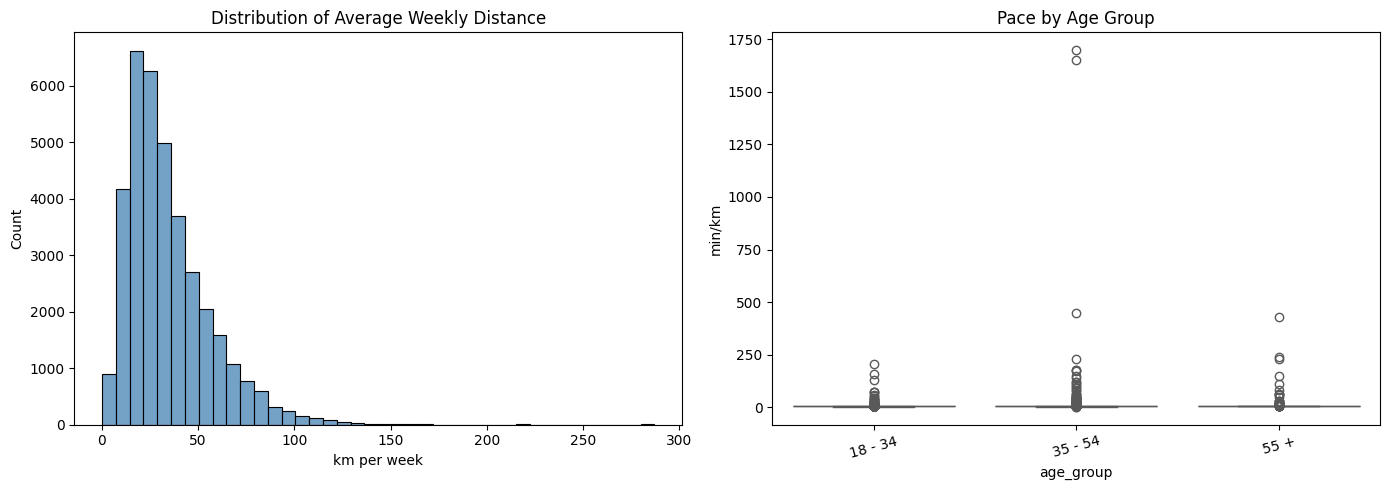

In [ ]:
# Convert to pandas for plotting
pdf = athlete_df.to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distance distribution
sns.histplot(pdf["avg_weekly_distance"], bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Average Weekly Distance")
axes[0].set_xlabel("km per week")

# Pace by age group
sns.boxplot(data=pdf, x="age_group", y="avg_pace", ax=axes[1], palette="Set2")
axes[1].set_title("Pace by Age Group")
axes[1].set_ylabel("min/km")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [ ]:
model_df = (
    athlete_df
    .filter(pl.col("avg_weekly_distance") > 5)
    .filter(pl.col("avg_pace") < 12)
    .select([
        "avg_weekly_distance",   # target
        "weeks_active",
        "avg_pace",
        "avg_speed",
        "gender",
        "age_group"
    ])
    .drop_nulls()
)

pdf_model = model_df.to_pandas()
pdf_model = pd.get_dummies(pdf_model, columns=["gender", "age_group"], drop_first=True)

print(f"Modelling dataset: {pdf_model.shape[0]:,} athletes")
print("Features:", pdf_model.columns.tolist())

Modelling dataset: 35,898 athletes
Features: ['avg_weekly_distance', 'weeks_active', 'avg_pace', 'avg_speed', 'gender_M', 'age_group_35 - 54', 'age_group_55 +']


In [ ]:
# Features and target
X = pdf_model.drop(columns=["avg_weekly_distance"])
y = pdf_model["avg_weekly_distance"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
model = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print("=== Model Performance ===")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.2f} km")
print(f"R²:   {r2_score(y_test, y_pred):.3f}")

=== Model Performance ===
MAE:  11.22 km
R²:   0.471


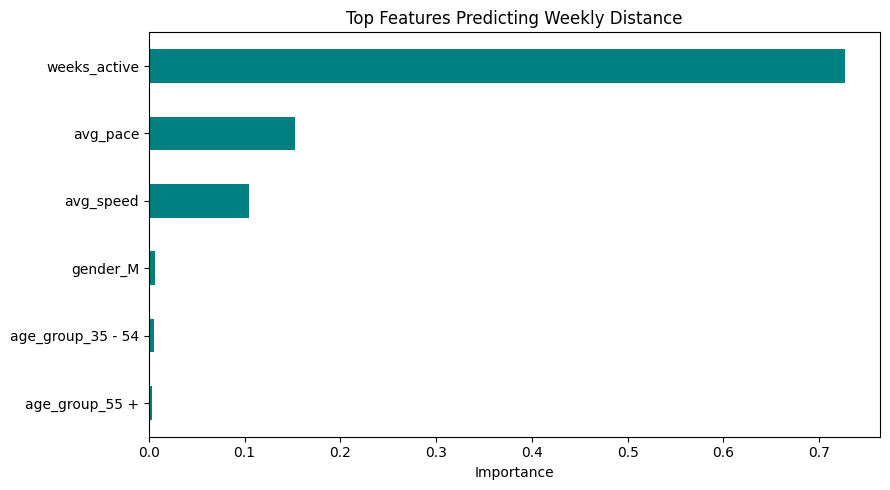

weeks_active         0.727202
avg_pace             0.153025
avg_speed            0.104455
gender_M             0.006773
age_group_35 - 54    0.005189
age_group_55 +       0.003357
dtype: float64


In [ ]:
# Feature importance
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importance.head(10).plot(kind="barh", color="teal")
plt.title("Top Features Predicting Weekly Distance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importance.head(8))

In [ ]:
# Save predictions for later use
results = X_test.copy()
results["actual_distance"] = y_test
results["predicted_distance"] = y_pred

results.to_parquet(DATA_PROCESSED / "model_predictions.parquet")
print("✅ Predictions saved")

✅ Predictions saved
